# Diagnose a shortcut and test a training repair

[Open in Colab](https://colab.research.google.com/github/frgfm/notebooks/blob/main/torch-cam/shortcut_repair.ipynb)

Train a tiny CNN to distinguish vertical (0) from horizontal (1) gray bars. A colored corner correlates with
training labels; on validation and test it is independent. GradCAM proposes a region, matched edits test
the proposal, and three training continuations test the repair. Repeat without the training correlation.
This extends the [validation audit](validation_audit.ipynb) with native PyTorch and merged TorchCAM APIs.

| Fixed final protocol | Choice |
|---|---|
| Seeds / images per split | 7, 17, 27; train 1,024, discovery 64, validation 256, test 1,024 |
| Training cue agreement | 95% target (94.92% after rounding); no-shortcut control 50% |
| Validation / test | Label × cue balanced; 256 test examples per group; paired across regimes |
| Model / training | Three convolutions, global pooling, linear head; centered inputs; Adam lr 0.003 |
| Matched training budgets | Shared 4-epoch pilot, then 32 epochs per arm, batch 64; 576 steps / 36,864 presentations |
| Arms | Unchanged; ordinary random border erasing; provisional CAM-guided border erasing |
| Edit budget | Same Bernoulli decisions (75%); one 8×8 tile, neutral fill 0.5 |
| Proposal / confirmation | Top 3 mean predicted-class GradCAM tile masses; neutralize and training-donor blend |
| Confirmation gate | Both edits: excess probability drop > 0.02 and descriptive bootstrap lower bound > 0 |

The workflow sees training/validation images, class labels, and the task contract that the central 16×16 region
defines the label. Oracle cue IDs stay separate and are used only for final group scoring. Guided training
uses the first supported tile, otherwise the top **provisional** CAM tile; absent usable maps it stays unchanged.
Unresolved diagnoses and failed interventions remain visible. No test result selects an edit or checkpoint.
The final test is generated only after all training finishes. CAM/confirmation compute is extra.

Run all cells in order in a fresh Linux/Colab Python 3.11 kernel. The tested CPU pins below are checked,
including TorchCAM's merged source revision. Headless execution with the pinned notebook tools:
`nb = nbformat.read(path, as_version=4); NotebookClient(nb, timeout=1800, kernel_name="python3").execute(); nbformat.write(nb, path)`.
Import `nbformat` and `NotebookClient` from `nbclient` first. Acceptance checks require integrity, not improvement.

In [1]:
import json
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, distribution, version

SOURCE_REVISION = "5a0bc4d439ad642a37ed301d94601048e8d32de8"
PINS = {
    "torch": "2.14.1+cpu",
    "numpy": "2.4.6",
    "matplotlib": "3.11.2",
    "Pillow": "12.3.0",
    "nbformat": "5.10.4",
    "nbclient": "0.10.2",
    "ipykernel": "6.30.1",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


def source_commit():
    try:
        direct_url = json.loads(distribution("torchcam").read_text("direct_url.json") or "{}")
        return direct_url.get("vcs_info", {}).get("commit_id")
    except PackageNotFoundError:
        return None


needs_setup = any(installed_version(p) != v for p, v in PINS.items()) or source_commit() != SOURCE_REVISION
if needs_setup:
    if any(p in sys.modules for p in ("torch", "torchcam", "numpy", "matplotlib", "PIL")):
        raise RuntimeError("Restart the kernel before changing loaded dependencies, then run all cells.")
    pip = [sys.executable, "-m", "pip", "install"]
    subprocess.check_call([
        *pip,
        "--index-url",
        "https://download.pytorch.org/whl/cpu",
        f"torch=={PINS['torch']}",
    ])
    subprocess.check_call([*pip, *[f"{p}=={v}" for p, v in PINS.items() if p != "torch"]])
    # Development commits share a version: replace TorchCAM without changing pinned dependencies.
    requirement = f"torchcam @ git+https://github.com/frgfm/torch-cam.git@{SOURCE_REVISION}"
    subprocess.check_call([*pip, "--no-deps", "--force-reinstall", requirement])

assert source_commit() == SOURCE_REVISION
assert all(installed_version(p) == v for p, v in PINS.items())
print("PASS: tested dependencies and merged TorchCAM revision.")

PASS: tested dependencies and merged TorchCAM revision.


In [2]:
%matplotlib inline
import copy
import hashlib
import math
import platform
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.nn import functional as F
from torchcam.explain import explain

torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
SEEDS, REGIMES, ARMS = (7, 17, 27), ("shortcut", "no_shortcut"), ("unchanged", "ordinary", "guided")
BATCH, EPOCHS = 64, (4, 32)
SIZES = {"train": 1024, "discovery": 64, "validation": 256, "test": 1024}
CENTRAL_NOISE, BAR_CONTRAST = 0.035, (0.25, 0.40)
TILES = [(y, x) for y in (0, 24) for x in (0, 8, 16, 24)]


def fingerprint(tensor):
    return hashlib.sha256(tensor.contiguous().numpy().tobytes()).hexdigest()


def model_hash(model):
    return hashlib.sha256(b"".join(t.numpy().tobytes() for t in model.state_dict().values())).hexdigest()


def table(headers, rows):
    display(Markdown("\n".join(["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers), *rows])))

## Controlled images and paired training

The generator injects the cue for benchmark construction; selectors and trainers receive only its public view.
Gray bars have jitter, contrast variation, and central noise. Erasing the permitted border preserves all label
pixels. Arms share pilot weights, reset Adam identically, and replay the same minibatch and edit RNG.

In [3]:
def make_split(n, agreement, seed):
    """Return a public (image, label) view and a separate benchmark-only oracle."""
    g = torch.Generator().manual_seed(seed)
    labels = torch.arange(n) % 2
    cue = labels.clone()
    for label in (0, 1):
        indices = (labels == label).nonzero().flatten()
        indices = indices[torch.randperm(len(indices), generator=g)]
        cue[indices[: round((1 - agreement) * len(indices))]] = 1 - label
    images = torch.full((n, 3, 32, 32), 0.5)
    images[:, :, 8:24, 8:24] += CENTRAL_NOISE * torch.randn(n, 3, 16, 16, generator=g)
    foreground = torch.zeros(n, 32, 32, dtype=torch.bool)
    for i, label in enumerate(labels.tolist()):
        cy, cx = (16 + torch.randint(-2, 3, (2,), generator=g)).tolist()
        h, w = (10, 3) if label == 0 else (3, 10)
        foreground[i, cy - h // 2 : cy - h // 2 + h, cx - w // 2 : cx - w // 2 + w] = True
        contrast = BAR_CONTRAST[0] + (BAR_CONTRAST[1] - BAR_CONTRAST[0]) * torch.rand((), generator=g)
        images[i, :, foreground[i]] += contrast
    colors = torch.tensor([[0.9, 0.5, 0.1], [0.1, 0.5, 0.9]])
    images[:, :, :8, :8] = colors[cue, :, None, None]
    order = torch.randperm(n, generator=g)
    public = {"images": images[order].clamp(0, 1), "labels": labels[order]}
    return public, {"cue": cue[order]}

In [4]:
class TinyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.head = nn.Linear(16, 2)

    def forward(self, inputs):
        return self.head(self.features(inputs - 0.5).mean((2, 3)))


def train(model, view, epochs, seed, arm="unchanged", tile=None):
    g = torch.Generator().manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
    budget = {"steps": 0, "examples": 0}
    model.train()
    for _ in range(epochs):
        order = torch.randperm(len(view["labels"]), generator=g)
        locations = torch.randint(len(TILES), (len(order),), generator=g)
        edited = torch.rand(len(order), generator=g) < 0.75
        for start in range(0, len(order), BATCH):
            idx = order[start : start + BATCH]
            images = view["images"][idx].clone()
            if arm == "ordinary" or (arm == "guided" and tile is not None):
                for i in edited[start : start + BATCH].nonzero().flatten().tolist():
                    y, x = TILES[tile if arm == "guided" else int(locations[start + i])]
                    images[i, :, y : y + 8, x : x + 8] = 0.5
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(images), view["labels"][idx])
            assert torch.isfinite(loss)
            loss.backward()
            optimizer.step()
            budget["steps"] += 1
            budget["examples"] += len(idx)
    model.eval()
    return budget


def probabilities(model, images):
    with torch.no_grad():
        result = torch.cat([model(batch).softmax(1) for batch in images.split(BATCH)])
    assert torch.isfinite(result).all()
    return result

## CAM proposals and held-out tests

Every fixed discovery image is explained, including successes and mistakes. Rank normalized CAM mass over
eight task-permitted border tiles. Confirmation uses separate validation images: neutralize a candidate, or
blend it 50% with the same tile of a label-independent training donor. Translate **the same additive delta**
to each other tile as matched controls. Area and per-image L1/L2 change match; no clipping or label change.
Controls can introduce competing color evidence: an unresolved location gate cannot exclude global color
dependence. Probability drops measure sensitivity, not calibrated confidence or causal identification.

In [5]:
def proposals(model, view):
    rows, maps, masses = [], [], []
    for i, (image, label) in enumerate(zip(view["images"], view["labels"], strict=True)):
        try:
            result = explain(model, image[None], target_layer="features")
            cam = result.cams[result.predicted_class_idx][0]
            blank = bool(cam.max() == cam.min())
            full = F.interpolate(cam[None, None], (32, 32), mode="bilinear", align_corners=False)[0, 0]
            if not blank:
                masses.append([float(full[y : y + 8, x : x + 8].sum() / full.sum()) for y, x in TILES])
            maps.append(full)
            rows.append({
                "sample": i,
                "status": "blank" if blank else "ok",
                "correct": result.predicted_class_idx == int(label),
            })
        except Exception as error:  # Keep extraction failures; they are not negative shortcut evidence.
            rows.append({"sample": i, "status": "error", "error": f"{type(error).__name__}: {error}"})
    scores = np.mean(masses, axis=0) if masses else np.zeros(len(TILES))
    shortlist = np.argsort(-scores, kind="stable")[:3].tolist() if masses else []
    mean_map = torch.stack(maps).mean(0) if maps else torch.zeros(32, 32)
    return shortlist, rows, scores.tolist(), mean_map


def edits(images, tile, kind, donors):
    y, x = TILES[tile]
    patch = images[:, :, y : y + 8, x : x + 8]
    replacement = (
        torch.full_like(patch, 0.5) if kind == "neutralize" else (patch + donors[:, :, y : y + 8, x : x + 8]) / 2
    )
    delta = replacement - patch
    edited = []
    for position in [tile, *[t for t in range(len(TILES)) if t != tile]]:
        cy, cx = TILES[position]
        changed = images.clone()
        changed[:, :, cy : cy + 8, cx : cx + 8] += delta
        assert 0 <= changed.min() <= changed.max() <= 1
        assert torch.equal(changed[:, :, 8:24, 8:24], images[:, :, 8:24, 8:24])
        edited.append(changed)
    for changed in edited[1:]:
        for power in (1, 2):
            assert torch.allclose(
                (changed - images).abs().pow(power).flatten(1).sum(1),
                (edited[0] - images).abs().pow(power).flatten(1).sum(1),
                atol=1e-5,
            )
    return edited[0], edited[1:]


def confirm(model, validation, training, shortlist, seed):
    images, labels = validation["images"], validation["labels"]
    original = probabilities(model, images)
    prediction, idx = original.argmax(1), torch.arange(len(images))
    g = torch.Generator().manual_seed(seed + 4000)
    donors = training["images"][torch.randint(len(training["labels"]), (len(images),), generator=g)]
    records = []
    for tile in shortlist:
        for kind in ("neutralize", "donor_blend"):
            target, controls = edits(images, tile, kind, donors)
            changed = probabilities(model, target)
            control = torch.stack([probabilities(model, image) for image in controls])
            drop = original[idx, prediction] - changed[idx, prediction]
            control_drop = original[idx, prediction] - control[:, idx, prediction].mean(0)
            effect = (drop - control_drop).numpy()
            boot = np.random.default_rng(seed + 5000).choice(effect, (1000, len(effect))).mean(1)
            lo, hi = np.quantile(boot, [0.025, 0.975]).tolist()
            records.append({
                "tile": tile,
                "edit": kind,
                "target_drop": float(drop.mean()),
                "control_drop": float(control_drop.mean()),
                "excess": float(effect.mean()),
                "ci": [lo, hi],
                "original_accuracy": float((prediction == labels).float().mean()),
                "edited_accuracy": float((changed.argmax(1) == labels).float().mean()),
                "supported": float(effect.mean()) > 0.02 and lo > 0,
            })
    supported = next((t for t in shortlist if all(r["supported"] for r in records if r["tile"] == t)), None)
    return supported, records

shortcut/7: unresolved; guided tile=0.


shortcut/17: unresolved; guided tile=0.


shortcut/27: unresolved; guided tile=0.


no_shortcut/7: unresolved; guided tile=0.


no_shortcut/17: unresolved; guided tile=6.


no_shortcut/27: unresolved; guided tile=6.


| Regime | Seed | Tile | Edit | Excess drop [descriptive 95% CI] | Supported |
|---|---|---|---|---|---|
| shortcut | 7 | 0 | neutralize | 0.059 [-0.004, 0.123] | False |
| shortcut | 7 | 0 | donor_blend | 0.030 [-0.017, 0.077] | False |
| shortcut | 7 | 1 | neutralize | 0.000 [-0.000, 0.000] | False |
| shortcut | 7 | 1 | donor_blend | 0.000 [-0.000, 0.000] | False |
| shortcut | 7 | 7 | neutralize | 0.000 [-0.000, 0.000] | False |
| shortcut | 7 | 7 | donor_blend | 0.000 [-0.000, 0.000] | False |
| shortcut | 17 | 0 | neutralize | 0.062 [-0.010, 0.136] | False |
| shortcut | 17 | 0 | donor_blend | 0.032 [-0.022, 0.087] | False |
| shortcut | 17 | 1 | neutralize | -0.000 [-0.000, 0.000] | False |
| shortcut | 17 | 1 | donor_blend | -0.000 [-0.000, 0.000] | False |
| shortcut | 17 | 7 | neutralize | -0.000 [-0.000, 0.000] | False |
| shortcut | 17 | 7 | donor_blend | -0.000 [-0.000, 0.000] | False |
| shortcut | 27 | 0 | neutralize | 0.016 [-0.076, 0.114] | False |
| shortcut | 27 | 0 | donor_blend | 0.011 [-0.062, 0.075] | False |
| shortcut | 27 | 1 | neutralize | 0.000 [-0.000, 0.000] | False |
| shortcut | 27 | 1 | donor_blend | 0.000 [-0.000, 0.000] | False |
| shortcut | 27 | 7 | neutralize | 0.000 [-0.000, 0.000] | False |
| shortcut | 27 | 7 | donor_blend | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 7 | 0 | neutralize | -0.023 [-0.041, -0.004] | False |
| no_shortcut | 7 | 0 | donor_blend | -0.016 [-0.030, -0.001] | False |
| no_shortcut | 7 | 6 | neutralize | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 7 | 6 | donor_blend | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 7 | 5 | neutralize | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 7 | 5 | donor_blend | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 6 | neutralize | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 6 | donor_blend | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 5 | neutralize | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 5 | donor_blend | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 7 | neutralize | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 17 | 7 | donor_blend | 0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 6 | neutralize | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 6 | donor_blend | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 5 | neutralize | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 5 | donor_blend | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 7 | neutralize | -0.000 [-0.000, 0.000] | False |
| no_shortcut | 27 | 7 | donor_blend | -0.000 [-0.000, 0.000] | False |

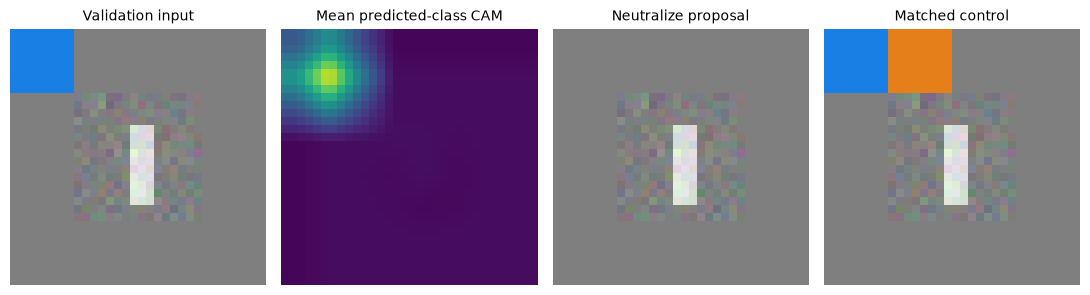

In [6]:
models, runs, diagnoses, seen_ids = {}, [], [], {}
for regime in REGIMES:
    for seed in SEEDS:
        views = {
            split: make_split(SIZES[split], 0.95 if split == "train" and regime == "shortcut" else 0.5, seed + offset)[
                0
            ]
            for split, offset in (("train", 0), ("discovery", 1000), ("validation", 2000))
        }
        ids = [fingerprint(image) for view in views.values() for image in view["images"]]
        assert len(ids) == len(set(ids))
        seen_ids[(regime, seed)] = set(ids)
        torch.manual_seed(seed)
        pilot = TinyClassifier()
        pilot_budget = train(pilot, views["train"], EPOCHS[0], seed)
        shortlist, probes, scores, mean_map = proposals(pilot, views["discovery"])
        supported, records = confirm(pilot, views["validation"], views["train"], shortlist, seed)
        chosen = supported if supported is not None else (shortlist[0] if shortlist else None)
        diagnoses.append({
            "regime": regime,
            "seed": seed,
            "status": "supported" if supported is not None else "unresolved",
            "chosen": chosen,
            "confirmed": supported,
            "cam_scores": scores,
            "probes": probes,
            "interventions": records,
        })
        for arm in ARMS:
            model = copy.deepcopy(pilot)
            assert model_hash(model) == model_hash(pilot)
            budget = train(model, views["train"], EPOCHS[1], seed + 6000, arm, chosen)
            models[(regime, seed, arm)] = model
            runs.append({
                "regime": regime,
                "seed": seed,
                "arm": arm,
                "final_hash": model_hash(model),
                **{name: pilot_budget[name] + budget[name] for name in budget},
            })
        if (regime, seed) == ("shortcut", SEEDS[0]):
            example = (views["validation"]["images"][:1], views["train"]["images"][:1], mean_map, chosen)
        print(f"{regime}/{seed}: {diagnoses[-1]['status']}; guided tile={chosen}.", flush=True)

table(
    ["Regime", "Seed", "Tile", "Edit", "Excess drop [descriptive 95% CI]", "Supported"],
    [
        f"| {d['regime']} | {d['seed']} | {r['tile']} | {r['edit']} | {r['excess']:.3f} [{r['ci'][0]:.3f}, {r['ci'][1]:.3f}] | {r['supported']} |"
        for d in diagnoses
        for r in d["interventions"]
    ],
)
original, donors, mean_map, tile = example
if tile is not None:
    changed, controls = edits(original, tile, "neutralize", donors)
    fig, axes = plt.subplots(1, 4, figsize=(11, 3))
    for ax, image, title in zip(
        axes,
        (original[0].permute(1, 2, 0), mean_map, changed[0].permute(1, 2, 0), controls[0][0].permute(1, 2, 0)),
        ("Validation input", "Mean predicted-class CAM", "Neutralize proposal", "Matched control"),
        strict=True,
    ):
        ax.imshow(image, vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Untouched test: average and worst-group accuracy

All models and repair choices are now frozen. Generate independent-cue test images using the unchanged final
seed offset 100,000; open oracle color IDs only to score the four label × cue groups. Worst-group accuracy
is the minimum **within each seed**, then averaged across seeds. Every seed and group is retained in the JSON.
The table reports mean ± sample SD and all seed-level accuracy/worst-group pairs; no favorable outcome is required.

In [7]:
test_hashes = {}
for regime in REGIMES:
    for seed in SEEDS:
        view, oracle = make_split(SIZES["test"], 0.5, seed + 100000)
        ids = [fingerprint(image) for image in view["images"]]
        assert len(ids) == len(set(ids)) and seen_ids[(regime, seed)].isdisjoint(ids)
        before = fingerprint(view["images"])
        for run in [r for r in runs if (r["regime"], r["seed"]) == (regime, seed)]:
            prediction = probabilities(models[(regime, seed, run["arm"])], view["images"]).argmax(1)
            correct, groups = prediction == view["labels"], []
            for label in (0, 1):
                for cue in (0, 1):
                    mask = (view["labels"] == label) & (oracle["cue"] == cue)
                    assert int(mask.sum()) == 256
                    groups.append({
                        "label": label,
                        "cue": cue,
                        "n": int(mask.sum()),
                        "accuracy": float(correct[mask].float().mean()),
                    })
            run.update(
                accuracy=float(correct.float().mean()),
                worst_group=min(g["accuracy"] for g in groups),
                groups=groups,
                predictions=prediction.tolist(),
            )
        assert fingerprint(view["images"]) == before
        test_hashes[f"{regime}/{seed}"] = before

summary, rows = [], []
for regime in REGIMES:
    for arm in ARMS:
        selected = [r for r in runs if r["regime"] == regime and r["arm"] == arm]
        values = np.array([[r["accuracy"], r["worst_group"]] for r in selected])
        mean, sd = values.mean(0), values.std(0, ddof=1)
        summary.append({"regime": regime, "arm": arm, "mean_accuracy_worst": mean.tolist(), "sd": sd.tolist()})
        pairs = ", ".join(f"{r['seed']}: {100 * r['accuracy']:.1f}/{100 * r['worst_group']:.1f}" for r in selected)
        rows.append(
            f"| {regime} | {arm} | {100 * mean[0]:.2f} ± {100 * sd[0]:.2f} | {100 * mean[1]:.2f} ± {100 * sd[1]:.2f} | {pairs} |"
        )
table(["Regime", "Arm", "Average % ± SD", "Worst-group % ± SD", "Seed: average/worst %"], rows)

| Regime | Arm | Average % ± SD | Worst-group % ± SD | Seed: average/worst % |
|---|---|---|---|---|
| shortcut | unchanged | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |
| shortcut | ordinary | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |
| shortcut | guided | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |
| no_shortcut | unchanged | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |
| no_shortcut | ordinary | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |
| no_shortcut | guided | 100.00 ± 0.00 | 100.00 ± 0.00 | 7: 100.0/100.0, 17: 100.0/100.0, 27: 100.0/100.0 |

## Acceptance and run record

Checks cover observed update budgets, split separation, untouched test images, finite results, and label/energy
preservation (checked during every validation edit). Separate blank/error probes verify that extraction failures
stay visible; a missing CAM is never evidence that the shortcut is absent. The JSON records the final protocol,
all 18 training outcomes and groups, model/test hashes, every rejected intervention, and every diagnostic probe.
Each export creates a new directory, so reruns do not collide with old artifacts.

In [8]:
expected = (sum(EPOCHS) * math.ceil(SIZES["train"] / BATCH), sum(EPOCHS) * SIZES["train"])
assert len(runs) == len(SEEDS) * len(REGIMES) * len(ARMS)
assert {(r["steps"], r["examples"]) for r in runs} == {expected}
assert all(np.isfinite([r["accuracy"], r["worst_group"]]).all() for r in runs)
assert all(len(d["probes"]) == SIZES["discovery"] for d in diagnoses)
for d in diagnoses:
    if d["chosen"] is None:
        arms = [r for r in runs if (r["regime"], r["seed"]) == (d["regime"], d["seed"])]
        assert len({r["final_hash"] for r in arms if r["arm"] != "ordinary"}) == 1
blank = TinyClassifier().eval()
for parameter in blank.parameters():
    nn.init.zeros_(parameter)
fault_view = {"images": torch.zeros(2, 3, 32, 32), "labels": torch.tensor([0, 1])}
blank_shortlist, blank_rows, _, _ = proposals(blank, fault_view)
broken = TinyClassifier().eval()
broken.forward = lambda inputs: inputs[:, :2].mean((2, 3))  # Selected feature layer never runs.
error_shortlist, error_rows, _, _ = proposals(broken, fault_view)
assert len(blank_rows) == len(error_rows) == 2
assert not blank_shortlist and not error_shortlist
assert all(r["status"] == "blank" for r in blank_rows) and all(r["status"] == "error" for r in error_rows)

protocol = {
    "seeds": SEEDS,
    "regimes": REGIMES,
    "arms": ARMS,
    "sizes": SIZES,
    "epochs": EPOCHS,
    "batch": BATCH,
    "optimizer": "Adam lr=0.003; shared pilot; reset at continuation",
    "noise": CENTRAL_NOISE,
    "contrast": BAR_CONTRAST,
    "input_center": 0.5,
    "tiles_yx": TILES,
    "edit_probability": 0.75,
    "cam": "GradCAM(features), predicted raw logit; top 3 normalized tile masses",
    "selection": "both edits: excess >0.02 and bootstrap lower bound >0; else top provisional CAM tile",
    "bootstrap": "1000 image resamples, seed+5000; descriptive, uncorrected",
    "seed_offsets": {"discovery": 1000, "validation": 2000, "donors": 4000, "continuation": 6000, "test": 100000},
    "cue_agreement": "train shortcut 94.92%; all other splits 50%; oracle IDs only for test groups",
    "diagnostic_budget": "64 explanations + 48 edited validation passes per full shortlist; extra compute",
}
runtime = {
    "python": platform.python_version(),
    "torchcam_revision": source_commit(),
    "torchcam": version("torchcam"),
    "cpu_threads": torch.get_num_threads(),
    **PINS,
}
output = Path(tempfile.mkdtemp(prefix="torchcam-shortcut-")) / "experiment.json"
report = {
    "protocol": protocol,
    "runtime": runtime,
    "runs": runs,
    "diagnoses": diagnoses,
    "summary": summary,
    "test_hashes": test_hashes,
    "fault_checks": {"blank": blank_rows, "error": error_rows},
}
output.write_text(json.dumps(report, indent=2, allow_nan=False) + "\n", encoding="utf-8")
assert json.loads(output.read_text())["summary"] == summary
print(f"PASS: acceptance checks; complete final run record: {output}")

PASS: acceptance checks; complete final run record: /tmp/torchcam-shortcut-1ha4k25d/experiment.json


## Result and limits

The committed CPU run reaches **100% average and worst-group accuracy in all three arms**, with 0 percentage-point
SD across seeds in both regimes. All guided-minus-ordinary/unchanged differences are zero. Every confirmation
gate remains unresolved. Continued unchanged training solves the task too: **no CAM-guided repair advantage**
is demonstrated at this final accuracy ceiling, and accuracy does not establish cue-invariant logits.

This is a synthetic, task-informed example with three seeds and deliberately supplied independent-cue validation,
not a general bias detector. The no-shortcut control removes the injected correlation, not every possible shortcut.
Controls can change globally pooled color evidence as much as the target edit. Bootstrap intervals concern images;
final SD concerns seeds. Neither is a population confidence interval. No non-CAM targeted selector is trained,
so even a positive workflow comparison would not isolate CAM's incremental value.

## Preserve the unsuccessful initial attempt

The first executed protocol used contrast 0.10–0.26, noise SD 0.055, uncentered inputs, and 4 + 12 epochs.
The no-shortcut classifier also stayed at chance on validation. Initial guided training acted only when both
confirmation edits passed; no region passed both. All initial outcomes and tested interventions are preserved below.

The final protocol was developed using training/validation evidence: brighter bars, centering, 32 continuation
epochs, and provisional repair. Because the initial test had been viewed, the final comparison used fresh seeds
(test offset 100,000 instead of 3,000), frozen before first scoring. This was not preregistered.

Initial test groups are ordered label/cue **00, 01, 10, 11**, each with n=256. Numbers are percentages.

| Regime | Seed | Arm | Average / worst-group | Group accuracies |
|---|---|---|---|---|
| shortcut | 7 | unchanged | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 7 | ordinary | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 7 | guided | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 17 | unchanged | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 17 | ordinary | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 17 | guided | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 27 | unchanged | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 27 | ordinary | 50 / 0 | 100, 0, 0, 100 |
| shortcut | 27 | guided | 50 / 0 | 100, 0, 0, 100 |
| no_shortcut | 7 | unchanged | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 7 | ordinary | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 7 | guided | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 17 | unchanged | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 17 | ordinary | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 17 | guided | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 27 | unchanged | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 27 | ordinary | 50 / 0 | 0, 0, 100, 100 |
| no_shortcut | 27 | guided | 50 / 0 | 0, 0, 100, 100 |

All initial diagnoses stayed unresolved. Probe counts preserve failed/blank extraction coverage.

| Regime | Seed | OK / blank / error | Correct probes |
|---|---|---|---|
| shortcut | 7 | 64 / 0 / 0 | 32 |
| shortcut | 17 | 64 / 0 / 0 | 32 |
| shortcut | 27 | 64 / 0 / 0 | 32 |
| no_shortcut | 7 | 0 / 64 / 0 | 32 |
| no_shortcut | 17 | 0 / 64 / 0 | 32 |
| no_shortcut | 27 | 64 / 0 / 0 | 32 |

Each operator gate requires excess >0.02 and positive lower interval bound; the region gate requires both operators.

| Regime | Seed | Tile | Edit | Target / control drop | Excess [descriptive 95% CI] | Edited accuracy % | Operator gate |
|---|---|---|---|---|---|---|---|
| shortcut | 7 | 0 | neutralize | 0.318433 / 0.267255 | 0.051178 [-0.001071, 0.103391] | 50.0000 | False |
| shortcut | 7 | 0 | donor_blend | 0.159081 / 0.133575 | 0.025506 [-0.013633, 0.064649] | 47.6562 | False |
| shortcut | 7 | 1 | neutralize | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 7 | 1 | donor_blend | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 7 | 6 | neutralize | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 7 | 6 | donor_blend | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 17 | 0 | neutralize | 0.071927 / 0.057700 | 0.014227 [0.010836, 0.017624] | 50.0000 | False |
| shortcut | 17 | 0 | donor_blend | 0.037089 / 0.029746 | 0.007342 [0.004800, 0.010055] | 46.8750 | False |
| shortcut | 17 | 1 | neutralize | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 17 | 1 | donor_blend | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 17 | 5 | neutralize | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 17 | 5 | donor_blend | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 27 | 0 | neutralize | 0.152221 / 0.130944 | 0.021276 [0.003352, 0.038086] | 50.0000 | True |
| shortcut | 27 | 0 | donor_blend | 0.070467 / 0.061133 | 0.009334 [-0.002195, 0.022326] | 47.2656 | False |
| shortcut | 27 | 1 | neutralize | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 27 | 1 | donor_blend | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 27 | 2 | neutralize | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| shortcut | 27 | 2 | donor_blend | 0.000000 / -0.000000 | 0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 6 | neutralize | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 6 | donor_blend | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 5 | neutralize | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 5 | donor_blend | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 7 | neutralize | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |
| no_shortcut | 27 | 7 | donor_blend | 0.000000 / 0.000000 | -0.000000 [-0.000000, 0.000000] | 50.0000 | False |